In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

In [3]:
df = pd.read_csv("uk_universities.csv")

In [4]:
df.head()

,University_name,Region,Founded_year,Motto,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),...,Student_satisfaction,Student_enrollment,Academic_staff,Control_type,Academic_Calender,Campus_setting,Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Website
0,University of Cambridge,East of England,1209,"From here, light and sacred draughts",1,4,94.1,6.5,21750,23187,...,85.50%,"20,000-24,999","over-5,000",Public,Trimesters,Urban,12000,52.2054,0.1132,www.cam.ac.uk
1,University of Oxford,South East England,1096,The Lord is my light,2,2,93.3,6.5,21770,19888,...,86.50%,"25,000-29,999","over-5,000",Public,Trimesters,Urban,11500,51.7548,-1.2544,www.ox.ac.uk
2,University of St Andrews,Scotland,1413,Ever to excel,3,86,75.8,6.5,17040,15440,...,87.90%,"10,000-14,999","1,000-1,499",Public,Semesters,Suburban,12000,56.3417,-2.7943,www.st-andrews.ac.uk
3,Imperial College London,London,1907,Knowledge is the adornment and safeguard of th...,4,8,86.6,6.5,23500,29900,...,77.90%,"15,000-19,999","4,000-4,499",Public,Continuous,Urban,10700,51.4988,-0.1749,www.ic.ac.uk
4,Loughborough University,East Midlands,1966,"With Truth, Knowledge and Labour",5,404,72.8,5.5,16400,16400,...,85.80%,"15,000-19,999","1,500-1,999",Public,Semesters,Suburban,9398,52.7650,-1.2321,www.lboro.ac.uk/


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   University_name                                131 non-null    object 
 1   Region                                         131 non-null    object 
 2   Founded_year                                   131 non-null    int64  
 3   Motto                                          114 non-null    object 
 4   UK_rank                                        131 non-null    int64  
 5   World_rank                                     131 non-null    int64  
 6   CWUR_score                                     84 non-null     float64
 7   Minimum_IELTS_score                            131 non-null    float64
 8   UG_average_fees_(in_pounds)                    131 non-null    int64  
 9   PG_average_fees_(in_pounds)                    131 non

In [7]:
df.describe()

,Founded_year,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude
count,131.000000,131.000000,131.00000,84.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,1925.221374,65.900763,1097.59542,73.960714,4.946565,12537.450382,13099.763359,8644.732824,52.749708,-1.673287
std,139.040187,37.922158,1145.00106,6.351473,0.617850,2555.318861,3106.398149,1579.049538,1.638257,1.503049
min,1096.000000,1.000000,2.00000,65.900000,4.000000,8350.000000,6000.000000,5500.000000,50.171300,-6.675200
25%,1896.000000,33.500000,196.00000,68.675000,4.500000,10758.000000,11250.000000,7710.500000,51.499700,-2.748000
50%,1966.000000,65.000000,691.00000,72.600000,4.500000,12000.000000,12500.000000,8217.000000,52.407400,-1.551600
75%,1992.000000,98.000000,1569.00000,77.700000,5.500000,13825.000000,14182.500000,9457.500000,53.608500,-0.388150
max,2013.000000,131.000000,5253.00000,94.100000,6.500000,23500.000000,29900.000000,15000.000000,57.164800,1.296700


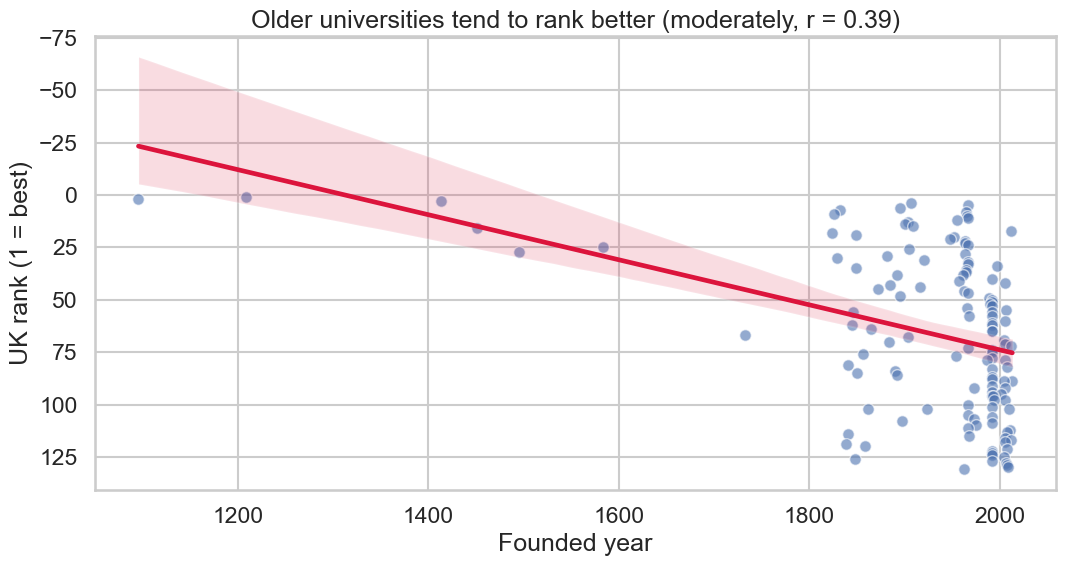

In [14]:
# Relationship between year founded and UK rank
corr_year = df["Founded_year"].corr(df["UK_rank"])

# Build a conclusion-style title from the actual correlation
# (UK_rank: 1 = best, so a positive corr means newer universities rank worse)
strength = "strongly" if abs(corr_year) >= 0.5 else "moderately" if abs(corr_year) >= 0.3 else "weakly"
if corr_year > 0:
    conclusion = f"Older universities tend to rank better ({strength}, r = {corr_year:.2f})"
else:
    conclusion = f"Newer universities tend to rank better ({strength}, r = {corr_year:.2f})"

plt.figure(figsize=(11, 6))
sns.regplot(
    data=df, x="Founded_year", y="UK_rank",
    scatter_kws={"alpha": 0.6, "edgecolor": "white", "s": 70},
    line_kws={"color": "crimson"},
)

plt.xlabel("Founded year")
plt.ylabel("UK rank (1 = best)")
plt.title(conclusion)
plt.gca().invert_yaxis()  # so rank 1 (best) is at the top
plt.tight_layout()
plt.show()

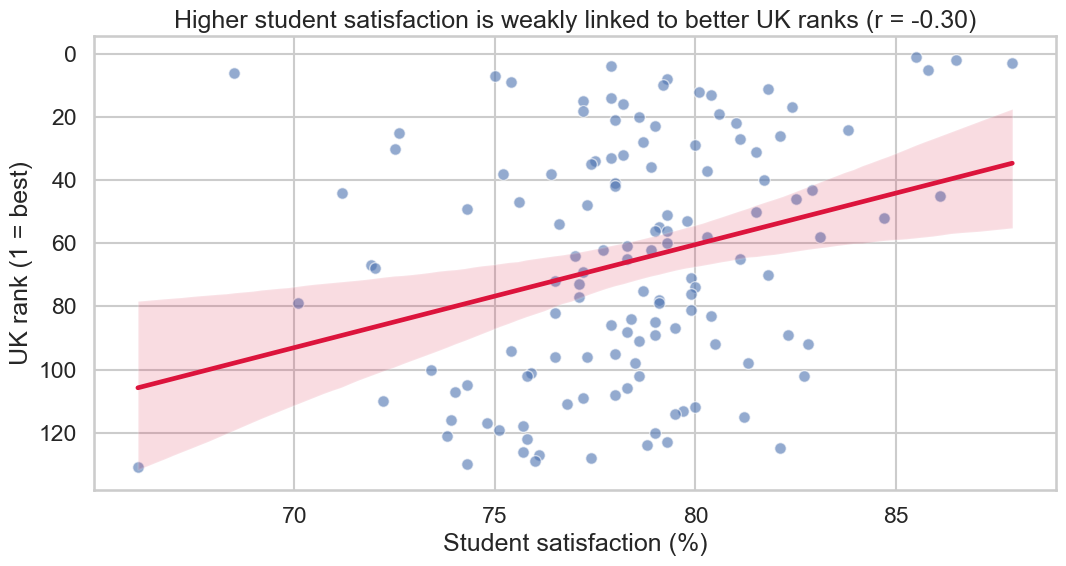

In [15]:
# Student_satisfaction is text like "85.50%" -> convert to a numeric percentage
df["Satisfaction_pct"] = pd.to_numeric(
    df["Student_satisfaction"].str.replace("%", "", regex=False),
    errors="coerce",
)

# Correlation (drop rows where either value is missing)
mask = df["Satisfaction_pct"].notna() & df["UK_rank"].notna()
corr_sat = df.loc[mask, "Satisfaction_pct"].corr(df.loc[mask, "UK_rank"])

# Conclusion-style title (UK_rank: 1 = best, so a negative corr is the intuitive direction)
strength = "strongly" if abs(corr_sat) >= 0.5 else "moderately" if abs(corr_sat) >= 0.3 else "weakly"
if corr_sat < 0:
    conclusion = f"Higher student satisfaction is {strength} linked to better UK ranks (r = {corr_sat:.2f})"
else:
    conclusion = f"Student satisfaction barely tracks UK rank (r = {corr_sat:.2f})"

plt.figure(figsize=(11, 6))
sns.regplot(
    data=df[mask], x="Satisfaction_pct", y="UK_rank",
    scatter_kws={"alpha": 0.6, "edgecolor": "white", "s": 70},
    line_kws={"color": "crimson"},
)

plt.xlabel("Student satisfaction (%)")
plt.ylabel("UK rank (1 = best)")
plt.title(conclusion)
plt.gca().invert_yaxis()  # so rank 1 (best) is at the top
plt.tight_layout()
plt.show()

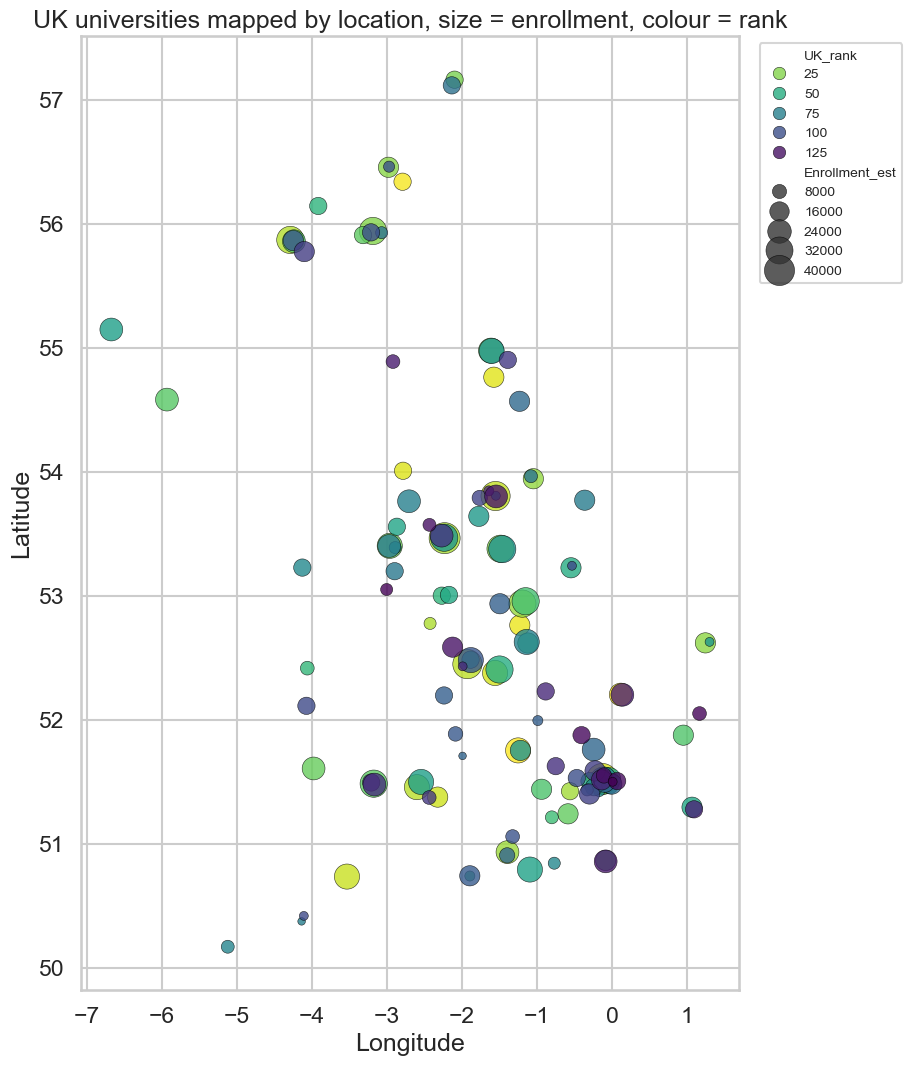

In [16]:
# Student_enrollment is a text bucket like "20,000-24,999" -> use the midpoint as a numeric size
nums = df["Student_enrollment"].str.replace(",", "", regex=False).str.findall(r"\d+")
df["Enrollment_est"] = nums.apply(
    lambda lst: np.mean([int(x) for x in lst]) if lst else np.nan
)

plt.figure(figsize=(9, 11))
ax = sns.scatterplot(
    data=df,
    x="Longitude", y="Latitude",
    size="Enrollment_est",
    hue="UK_rank",
    palette="viridis_r",   # bright = best (rank 1), dark = worst
    sizes=(30, 500),
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
)

# Make the map geographically proportioned for UK latitudes
ax.set_aspect(1 / np.cos(np.radians(df["Latitude"].mean())))

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("UK universities mapped by location, size = enrollment, colour = rank")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

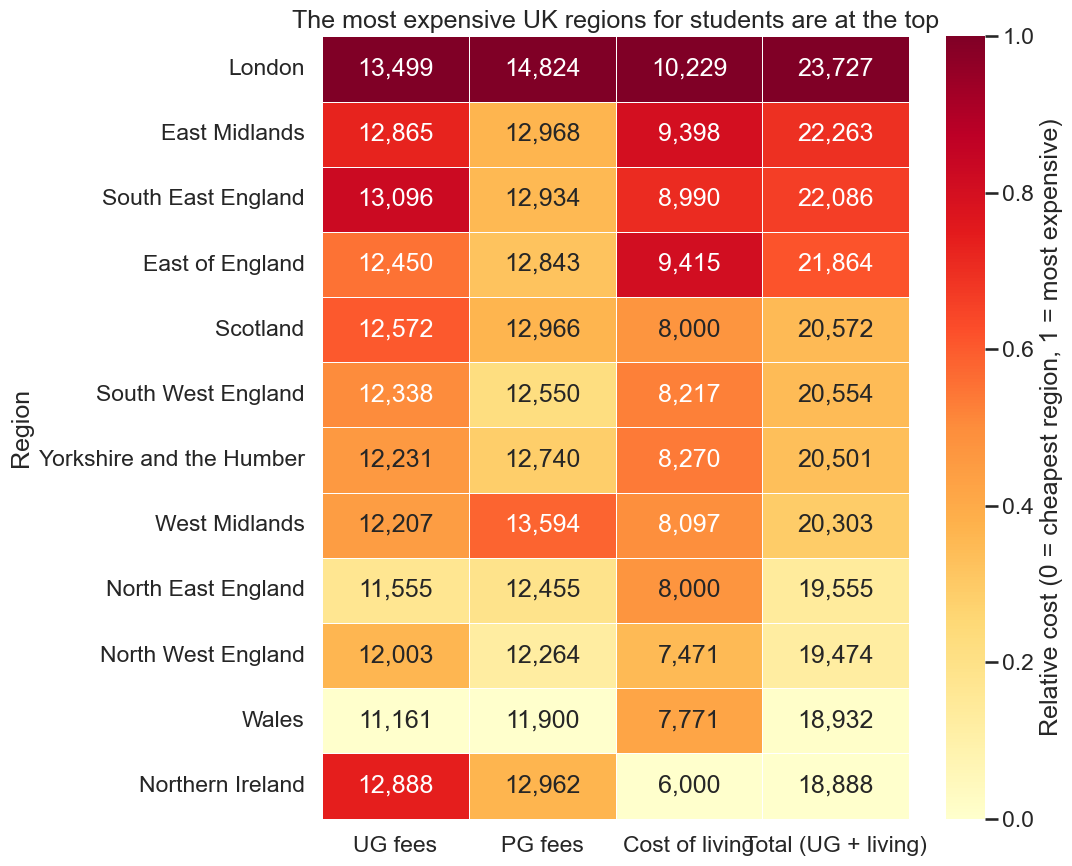

Most expensive regions by total annual cost (UG fees + cost of living):

1. London: £23,727 per year
2. East Midlands: £22,263 per year
3. South East England: £22,086 per year


In [17]:
# Average cost components per region
cost_cols = {
    "UG fees": "UG_average_fees_(in_pounds)",
    "PG fees": "PG_average_fees_(in_pounds)",
    "Cost of living": "Estimated_cost_of_living_per_year_(in_pounds)",
}
region_costs = df.groupby("Region")[list(cost_cols.values())].mean()
region_costs.columns = list(cost_cols.keys())

# Realistic annual cost for an undergrad = UG fees + cost of living
region_costs["Total (UG + living)"] = region_costs["UG fees"] + region_costs["Cost of living"]

# Order regions from most to least expensive overall
region_costs = region_costs.sort_values("Total (UG + living)", ascending=False)

# Colour by per-column normalised rank, but label with real pounds
norm = (region_costs - region_costs.min()) / (region_costs.max() - region_costs.min())

plt.figure(figsize=(11, 9))
sns.heatmap(
    norm,
    annot=region_costs, fmt=",.0f",
    cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Relative cost (0 = cheapest region, 1 = most expensive)"},
)
plt.title("The most expensive UK regions for students are at the top")
plt.xlabel("")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# Identify the most expensive regions
top = region_costs["Total (UG + living)"].head(3)
print("Most expensive regions by total annual cost (UG fees + cost of living):\n")
for i, (region, total) in enumerate(top.items(), 1):
    print(f"{i}. {region}: £{total:,.0f} per year")

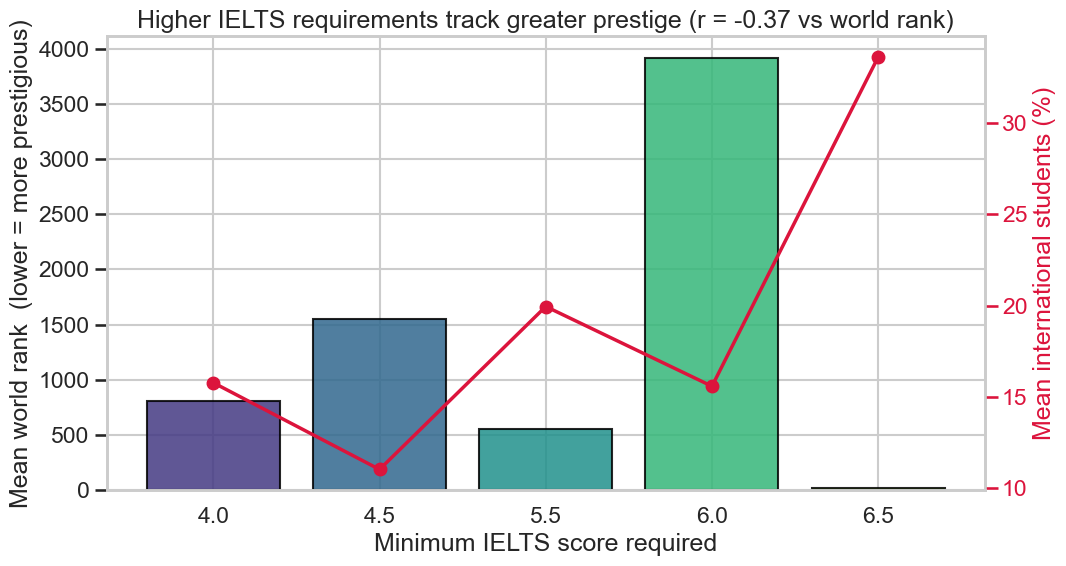

                     mean_world_rank  mean_intl_pct   n
Minimum_IELTS_score                                    
4.0                            811.0           15.8   6
4.5                           1547.1           11.0  70
5.5                            553.5           20.0  48
6.0                           3916.0           15.6   1
6.5                             22.8           33.6   6

IELTS vs world rank correlation:           -0.37  (negative = higher IELTS -> more prestige)
IELTS vs international students % correlation: +0.55


In [18]:
# International_students is text like "20.20%" -> numeric percent
df["Intl_students_pct"] = pd.to_numeric(
    df["International_students"].str.replace("%", "", regex=False), errors="coerce"
)

# Mean prestige & international intake at each IELTS requirement level
by_ielts = df.groupby("Minimum_IELTS_score").agg(
    mean_world_rank=("World_rank", "mean"),
    mean_intl_pct=("Intl_students_pct", "mean"),
    n=("World_rank", "size"),
)

# Correlations at the university level (World_rank: lower number = more prestigious)
corr_rank = df["Minimum_IELTS_score"].corr(df["World_rank"])
corr_intl = df["Minimum_IELTS_score"].corr(df["Intl_students_pct"])

if corr_rank < 0:
    conclusion = f"Higher IELTS requirements track greater prestige (r = {corr_rank:.2f} vs world rank)"
else:
    conclusion = f"Higher IELTS requirements do NOT imply more prestige (r = {corr_rank:+.2f} vs world rank)"

x = by_ielts.index.astype(str)
fig, ax1 = plt.subplots(figsize=(11, 6))

# Bars: mean world rank (shorter bar = better/more prestigious)
ax1.bar(x, by_ielts["mean_world_rank"],
        color=sns.color_palette("viridis", len(x)), alpha=0.85, edgecolor="black")
ax1.set_xlabel("Minimum IELTS score required")
ax1.set_ylabel("Mean world rank  (lower = more prestigious)")

# Line: mean international students % on a second axis
ax2 = ax1.twinx()
ax2.plot(x, by_ielts["mean_intl_pct"], color="crimson", marker="o", linewidth=2.5)
ax2.set_ylabel("Mean international students (%)", color="crimson")
ax2.tick_params(axis="y", colors="crimson")
ax2.grid(False)

plt.title(conclusion)
fig.tight_layout()
plt.show()

print(by_ielts.round(1).to_string())
print(f"\nIELTS vs world rank correlation:           {corr_rank:+.2f}  (negative = higher IELTS -> more prestige)")
print(f"IELTS vs international students % correlation: {corr_intl:+.2f}")

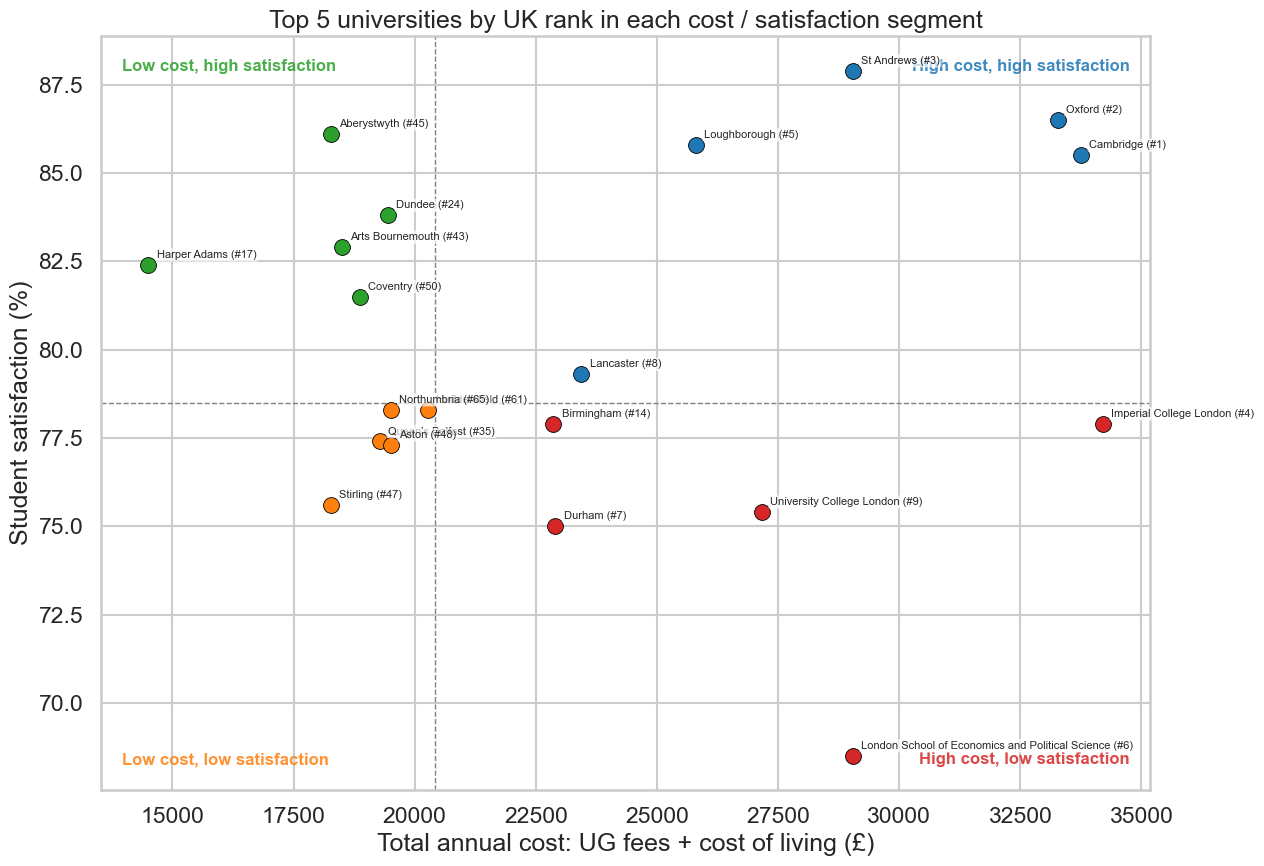

In [25]:
# Total annual cost = UG fees + cost of living
df["Total_cost"] = (
    df["UG_average_fees_(in_pounds)"] + df["Estimated_cost_of_living_per_year_(in_pounds)"]
)
df["Satisfaction_pct"] = pd.to_numeric(
    df["Student_satisfaction"].str.replace("%", "", regex=False), errors="coerce"
)

plot_df = df.dropna(subset=["Total_cost", "Satisfaction_pct"]).copy()

# Quadrant boundaries from the full population
cost_med = plot_df["Total_cost"].median()
sat_med = plot_df["Satisfaction_pct"].median()

def segment(row):
    hi_cost = row["Total_cost"] >= cost_med
    hi_sat = row["Satisfaction_pct"] >= sat_med
    if not hi_cost and hi_sat:
        return "Low cost, high satisfaction"
    if hi_cost and hi_sat:
        return "High cost, high satisfaction"
    if not hi_cost and not hi_sat:
        return "Low cost, low satisfaction"
    return "High cost, low satisfaction"

plot_df["Segment"] = plot_df.apply(segment, axis=1)

# Keep ONLY the 5 best-ranked universities (lowest UK_rank) in each segment
top5 = (
    plot_df.sort_values("UK_rank")
    .groupby("Segment", group_keys=False)
    .head(5)
)

# Shorten long names so labels are compact and readable
def short_name(name):
    return (name.replace("University of ", "")
                .replace("The University of ", "")
                .replace(" University", ""))

seg_colors = {
    "Low cost, high satisfaction":  "#2ca02c",  # green = best value
    "High cost, high satisfaction": "#1f77b4",
    "Low cost, low satisfaction":   "#ff7f0e",
    "High cost, low satisfaction":  "#d62728",  # red = worst value
}

fig, ax = plt.subplots(figsize=(13, 9))

# Quadrant divider lines
ax.axvline(cost_med, color="grey", linestyle="--", linewidth=1)
ax.axhline(sat_med, color="grey", linestyle="--", linewidth=1)

# Plot only the 20 selected universities
for seg, color in seg_colors.items():
    sub = top5[top5["Segment"] == seg]
    ax.scatter(sub["Total_cost"], sub["Satisfaction_pct"],
               s=130, color=color, edgecolor="black", linewidth=0.6, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(
            f"{short_name(r['University_name'])} (#{r['UK_rank']})",
            (r["Total_cost"], r["Satisfaction_pct"]),
            fontsize=8, xytext=(6, 5), textcoords="offset points", zorder=4,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        )

# Segment names placed in their quadrant corners (replaces the legend)
corners = {
    "Low cost, high satisfaction":  (0.02, 0.97, "left",  "top"),
    "High cost, high satisfaction": (0.98, 0.97, "right", "top"),
    "Low cost, low satisfaction":   (0.02, 0.03, "left",  "bottom"),
    "High cost, low satisfaction":  (0.98, 0.03, "right", "bottom"),
}
for seg, (fx, fy, ha, va) in corners.items():
    ax.text(fx, fy, seg, transform=ax.transAxes, ha=ha, va=va,
            fontsize=12, fontweight="bold", color=seg_colors[seg], alpha=0.85)

ax.set_xlabel("Total annual cost: UG fees + cost of living (£)")
ax.set_ylabel("Student satisfaction (%)")
ax.set_title("Top 5 universities by UK rank in each cost / satisfaction segment")
plt.tight_layout()
plt.show()

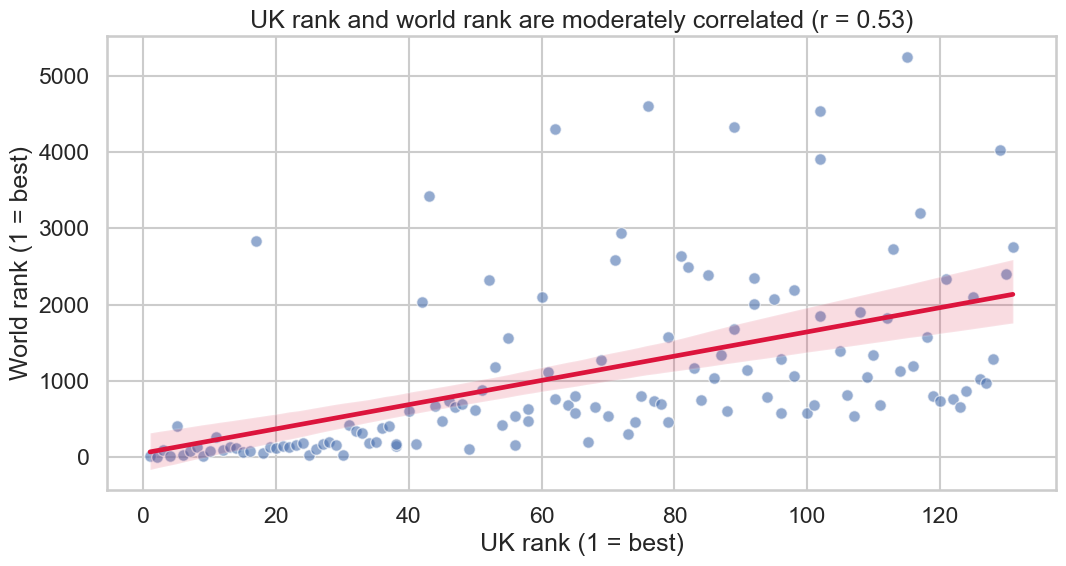

Correlation between UK rank and World rank: 0.53


In [26]:
# Are UK rank and World rank correlated? (both: lower number = better)
corr_ranks = df["UK_rank"].corr(df["World_rank"])

strength = ("strongly" if abs(corr_ranks) >= 0.7 else
            "moderately" if abs(corr_ranks) >= 0.4 else "weakly")
if corr_ranks > 0:
    conclusion = f"UK rank and world rank are {strength} correlated (r = {corr_ranks:.2f})"
else:
    conclusion = f"UK rank and world rank are not positively related (r = {corr_ranks:+.2f})"

plt.figure(figsize=(11, 6))
sns.regplot(
    data=df, x="UK_rank", y="World_rank",
    scatter_kws={"alpha": 0.6, "edgecolor": "white", "s": 70},
    line_kws={"color": "crimson"},
)

plt.xlabel("UK rank (1 = best)")
plt.ylabel("World rank (1 = best)")
plt.title(conclusion)
plt.tight_layout()
plt.show()

print(f"Correlation between UK rank and World rank: {corr_ranks:.2f}")

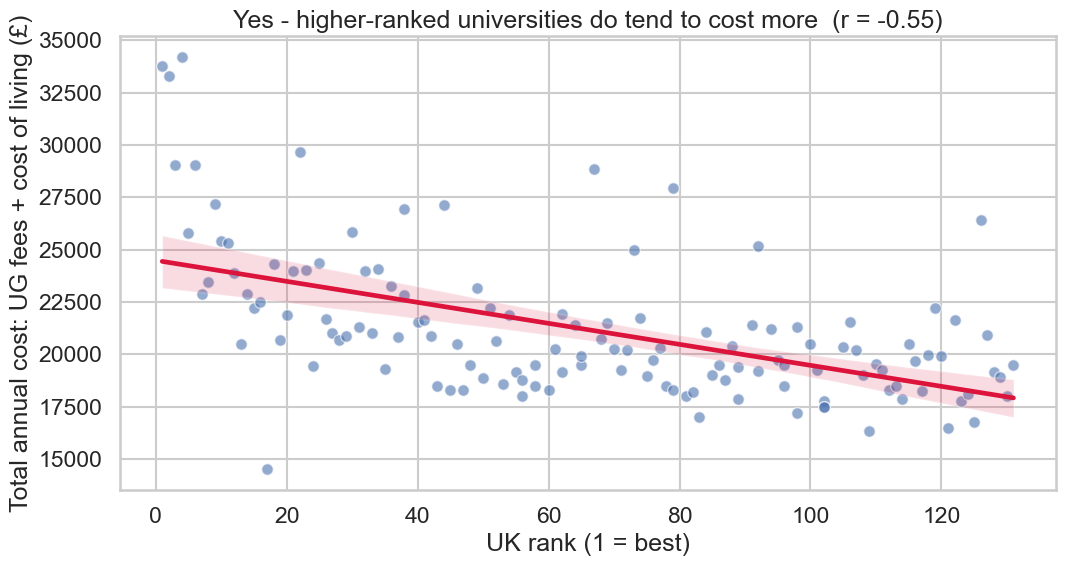

Correlation between UK rank and total cost: -0.55
  (negative = better-ranked universities cost more)

Mean total cost, top 20 universities: £25,131
Mean total cost, all others:          £20,471
Difference:                           £4,660  (more expensive at the top)

Most expensive universities overall (regardless of rank):
         University_name  UK_rank  Total_cost
 Imperial College London        4       34200
 University of Cambridge        1       33750
    University of Oxford        2       33270
      University of York       22       29679
University of St Andrews        3       29040


In [29]:
# Do better-ranked universities really cost more?
df["Total_cost"] = (
    df["UG_average_fees_(in_pounds)"] + df["Estimated_cost_of_living_per_year_(in_pounds)"]
)

# Correlation (UK_rank: 1 = best). Negative => better rank goes with higher cost.
corr_cost = df["UK_rank"].corr(df["Total_cost"])

# Compare the top 20 vs the rest
top_tier = df.nsmallest(20, "UK_rank")["Total_cost"].mean()
rest = df[~df.index.isin(df.nsmallest(20, "UK_rank").index)]["Total_cost"].mean()
gap = top_tier - rest

if corr_cost < -0.3:
    verdict = "Yes - higher-ranked universities do tend to cost more"
elif corr_cost > 0.3:
    verdict = "No - higher-ranked universities actually cost LESS"
else:
    verdict = "Not really - rank barely predicts cost"
conclusion = f"{verdict}  (r = {corr_cost:+.2f})"

plt.figure(figsize=(11, 6))
sns.regplot(
    data=df, x="UK_rank", y="Total_cost",
    scatter_kws={"alpha": 0.6, "edgecolor": "white", "s": 70},
    line_kws={"color": "crimson"},
)
plt.xlabel("UK rank (1 = best)")
plt.ylabel("Total annual cost: UG fees + cost of living (£)")
plt.title(conclusion)
plt.tight_layout()
plt.show()

print(f"Correlation between UK rank and total cost: {corr_cost:+.2f}")
print(f"  (negative = better-ranked universities cost more)\n")
print(f"Mean total cost, top 20 universities: £{top_tier:,.0f}")
print(f"Mean total cost, all others:          £{rest:,.0f}")
print(f"Difference:                           £{gap:,.0f}  "
      f"({'more' if gap > 0 else 'less'} expensive at the top)")
print("\nMost expensive universities overall (regardless of rank):")
print(df.nlargest(5, "Total_cost")[["University_name", "UK_rank", "Total_cost"]].to_string(index=False))